# Cite:
Jorntell, Henrik, and Kaan Kesgin. "Singular superlet transform achieves markedly improved time-frequency super-resolution for separating complex neural signals." bioRxiv (2023): 2023-02

In [1]:
#import required packages
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import cmcrameri.cm as cmc

#import the functions
from SingularSuperletPY import sst
from SingularSuperletPY import cwt #uncomment if you want to compare the method (SST) with continuous wavelet transform (CWT)

import superlets_package.morlet as morlet
import superlets_package.superlets as superlet

In [2]:
importlib.reload(sst)

<module 'SingularSuperletPY.sst' from '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY/SingularSuperletPY/sst.py'>

In [3]:
importlib.reload(cwt)

<module 'SingularSuperletPY.cwt' from '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY/SingularSuperletPY/cwt.py'>

In [4]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

# Create simulated EMG signals

In [5]:
Fs = 1024

In [6]:
from scipy.signal import chirp

t = np.arange(0, 1, 1/Fs) # Time from 0 to 5 seconds

f0 = 50  # Initial frequency
f1 = 10  # Final frequency

signal = chirp(t, f0=f0, t1=t[-1], f1=f1, method='linear')

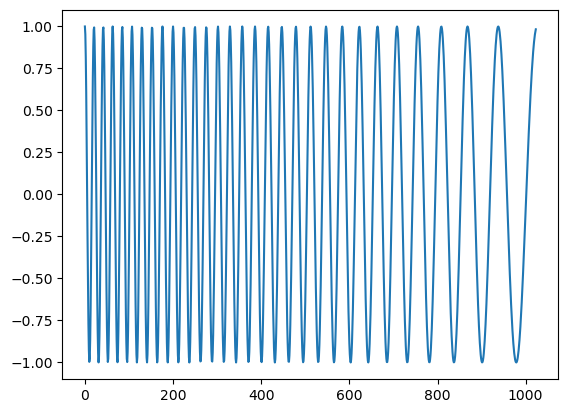

In [7]:
plt.plot(signal)

In [8]:
# burst_freqs = [70]
# f_shift = 10
# n_cycles = 5
# n_neighb_cycles = 5
# # 
# ys = []
# # 
# # # create a 0.1s blank signal to start
# ys.append(jnp.zeros(int(Fs*0.1)))
# # 
# for f in burst_freqs:
# #   # frequency contaminated signal
# #   ############ CONTAMINATION
# #   t = 1/f * n_cycles
# #   x = jnp.linspace(0, t, int(t * fs))
# #   y = jnp.sin(2*jnp.pi*f*x) + jnp.sin(2*jnp.pi*(f+f_shift)*x - jnp.pi/1.5)
# #   ys.append(y)
# #   ############ CONTAMINATION
# # 
# #   # time contaminated signal, 2 cycles later
#   ys.append(jnp.zeros(int(Fs*(1/f)*2)))
# #   
#   t2 = 1/f * n_neighb_cycles
#   x = jnp.linspace(0, t2, int(t2 * Fs))
#   y = jnp.sin(2*jnp.pi*f*x)
#   ys.append(y)
# # 
# #   # space between bursts of 0.1s
#   ys.append(jnp.zeros(int(Fs*0.1)))
# # 
# signal = jnp.concatenate(ys)

In [9]:
# plt.plot(signal)

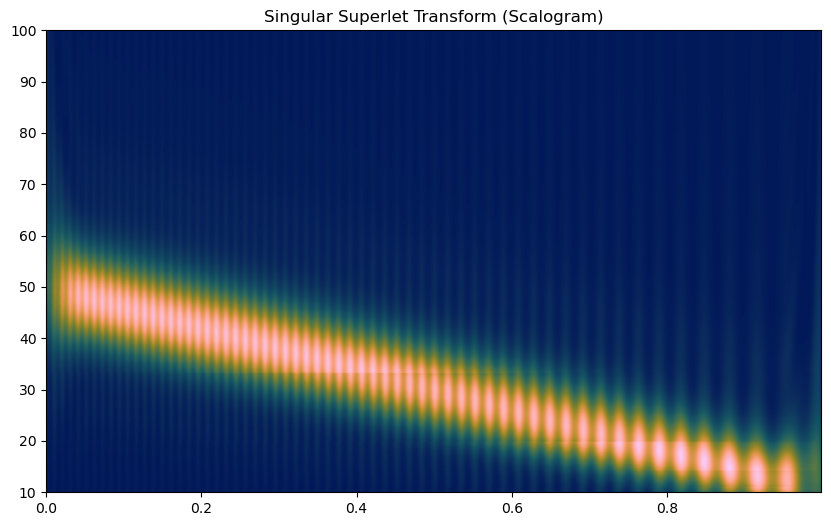

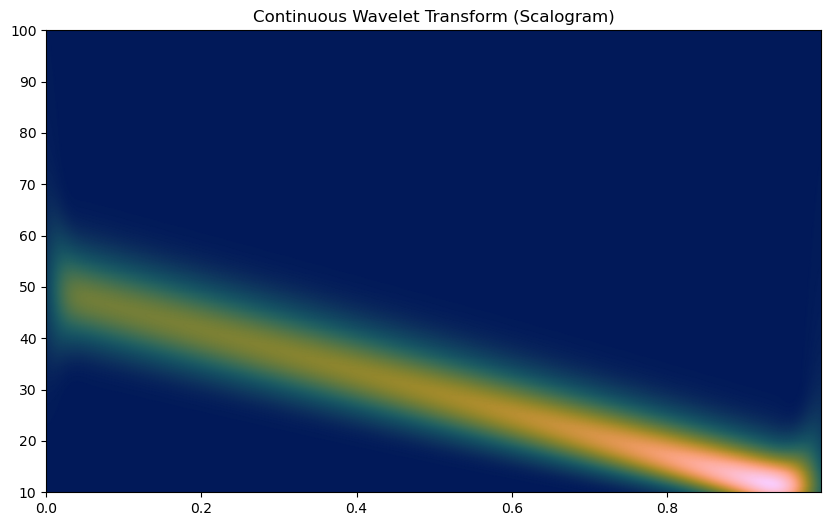

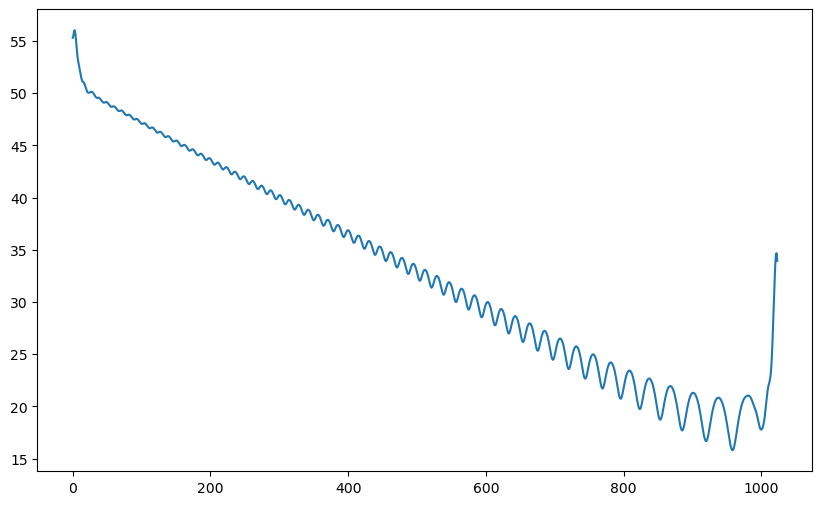

In [10]:
y = signal

frange = np.linspace(10,100,int(Fs/2)) 

norm = "energy" 
step = 10                # adaptive parameter for number of cycles increment per frequency band
baseCycle = 1   # number of baseline cycles to build the adaptive increments on 

# perform time frequency decomposition
sstRez, o_min, o_max = sst.sst(y, frange, Fs, baseCycle, norm, step) # perform sst,  returns the scalogram output that is frequencyPoints x timePoints
cwtRez = cwt.cwt(y, frange, Fs, baseCycle, norm, step) # perform cwt,  uncomment if you wish to make comparisons with cwt, returns the scalogram output that is frequencyPoints x timePoints

plt.figure(figsize=(10, 6))

plt.pcolormesh(t,frange, sstRez, shading='gouraud', cmap=cmc.batlow)
plt.title("Singular Superlet Transform (Scalogram)")
        
plt.figure(figsize=(10, 6))

plt.pcolormesh(t, frange, cwtRez, shading='gouraud', cmap=cmc.batlow)
plt.title("Continuous Wavelet Transform (Scalogram)")


instant_freq = np.sum(sstRez * frange[:, np.newaxis], axis=0) / np.sum(sstRez, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(instant_freq)

### SIMULATED SIGNAL = SIN + COS

In [12]:
Fs = 1000  # frecuencia de muestreo
burst_params = [
    # (frecuencia, inicio_en_segundos, duracion_en_segundos)
    (40, 0.2, 0.15),
    (70, 0.6, 0.1),
    (100, 1.0, 0.08)
]

# Duración total del experimento (por ejemplo, hasta un poco más que el último burst)
t_total = max(start + dur for _, start, dur in burst_params) + 0.2  # 0.2s extra
signal_2 = jnp.zeros(int(Fs * t_total))

burst_times = []

for f, start, dur in burst_params:
    start_idx = int(start * Fs)
    end_idx = int((start + dur) * Fs)
    t = jnp.arange(0, dur, 1/Fs)
    burst = jnp.sin(2 * jnp.pi * f * t)

    signal_2 = signal_2.at[start_idx:end_idx].set(burst)
    burst_times.append((start, start + dur))

# for f, start, end in burst_times:
#     print(f"Burst {f:>4} Hz: empieza en {start:.3f}s, acaba en {end:.3f}s, duración = {end-start:.3f}s")


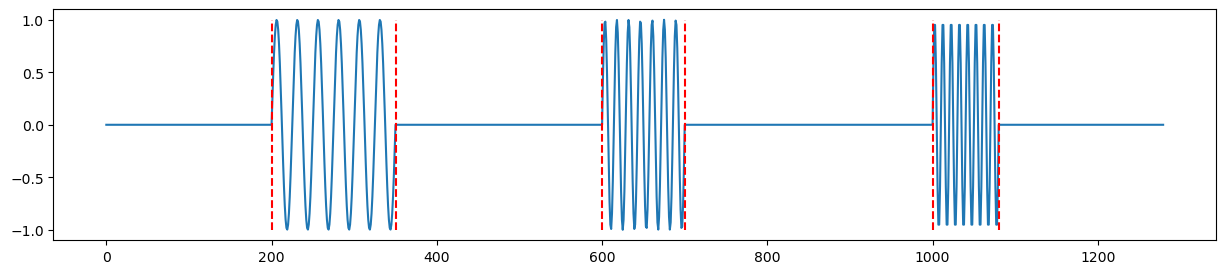

In [20]:
plt.figure(figsize=(15, 3))
plt.plot(signal_2)
for start, end in burst_times:
    plt.vlines([start*Fs, end*Fs], ymin=jnp.min(signal_2), ymax=jnp.max(signal_2), color='r', linestyles='--')

In [21]:
burst_times

[(0.2, 0.35), (0.6, 0.7), (1.0, 1.08)]

SST calculado en 0.253 segundos
CWT calculado en 0.508 segundos
Superlet calculado en 14.129 segundos


/var/folders/63/2lz089h509ddd045_5prskfm0000gn/T/ipykernel_31854/2577437764.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # deja espacio abajo para la colorbar


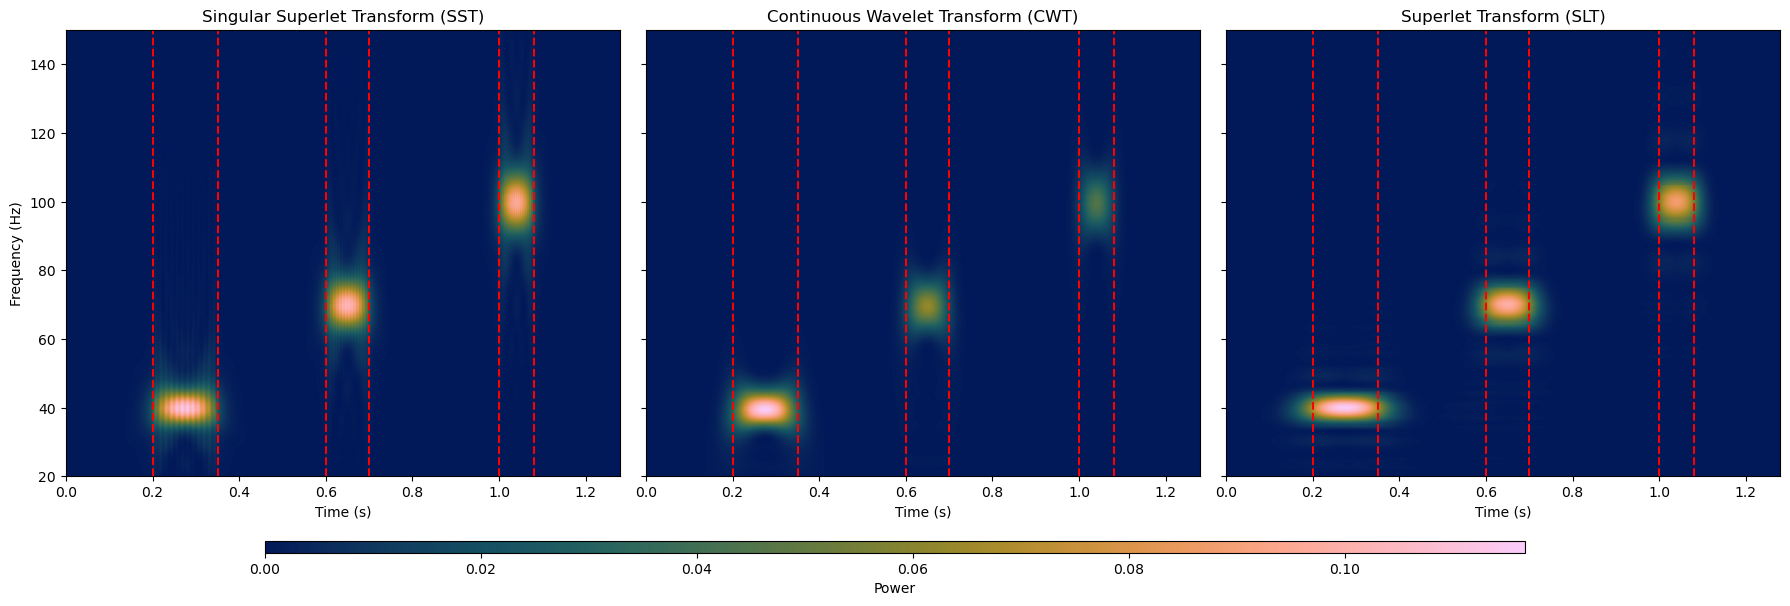

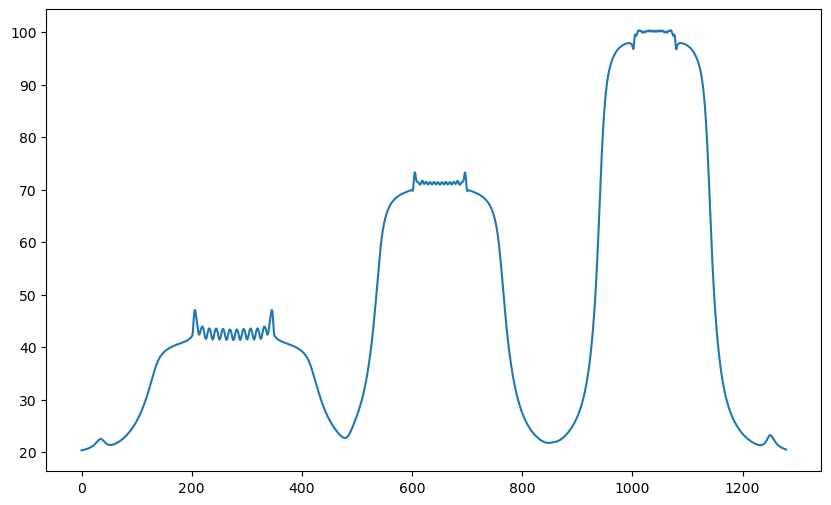

In [47]:
import time

y = signal_2

frange = np.linspace(20,150,int(Fs/2)) 

norm = "energy" 
step = 50              # adaptive parameter for number of cycles increment per frequency band
baseCycle = 5   # number of baseline cycles to build the adaptive increments on 

# perform time frequency decomposition
start_time = time.time()
sstRez, o_min, o_max = sst.sst(y, frange, Fs, baseCycle, norm, step) # perform sst,  returns the scalogram output that is frequencyPoints x timePoints
sst_time = time.time() - start_time
print(f"SST calculado en {sst_time:.3f} segundos")

cwtRez = cwt.cwt(y, frange, Fs, baseCycle, norm, step) # perform cwt,  uncomment if you wish to make comparisons with cwt, returns the scalogram output that is frequencyPoints x timePoints
cwt_time = time.time() - start_time
print(f"CWT calculado en {cwt_time:.3f} segundos")

wv, sltRez = superlet.adaptive_superlet_transform(y, frange, sampling_freq=Fs, base_cycle=baseCycle, min_order=o_min, max_order=o_max, mode="mul")
slt_time = time.time() - start_time
print(f"Superlet calculado en {slt_time:.3f} segundos")

fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

t = jnp.arange(len(signal_2)) / Fs

# 1. Singular Superlet Transform (SST)
for start, end in burst_times:
    axs[0].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
pcm0 = axs[0].pcolormesh(t, frange, sstRez, shading='gouraud', cmap=cmc.batlow)
axs[0].set_title("Singular Superlet Transform (SST)")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Frequency (Hz)")

# 2. Continuous Wavelet Transform (CWT)
for start, end in burst_times:
    axs[1].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
pcm1 = axs[1].pcolormesh(t, frange, cwtRez, shading='gouraud', cmap=cmc.batlow)
axs[1].set_title("Continuous Wavelet Transform (CWT)")
axs[1].set_xlabel("Time (s)")

# 3. Superlet Transform (SLT)
for start, end in burst_times:
    axs[2].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
scalogram_2 = np.array(jnp.abs(sltRez)**2)
pcm2 = axs[2].pcolormesh(t, frange, scalogram_2, shading='gouraud', cmap=cmc.batlow)
axs[2].set_title("Superlet Transform (SLT)")
axs[2].set_xlabel("Time (s)")

# Colorbar compartida horizontal abajo
fig.subplots_adjust(bottom=0.2)
cbar_ax = fig.add_axes([0.15, 0.07, 0.7, 0.02])  # [left, bottom, width, height] en figura (0-1)
cbar = fig.colorbar(pcm2, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Power')

plt.tight_layout(rect=[0, 0.1, 1, 1])  # deja espacio abajo para la colorbar
plt.show()

eps = 1e-12
instant_freq = np.sum(sstRez * frange[:, np.newaxis], axis=0) / (np.sum(sstRez, axis=0) + eps)

plt.figure(figsize=(10, 6))
plt.plot(instant_freq)

In [48]:
o_min

7.0

In [49]:
o_max

20.0

### Código original

In [ ]:
# #import required packages
# import numpy as np
# import matplotlib.pyplot as plt
# 
# #import the functions
# from SingularSuperletPY import sst
# # from SingularSuperletPY import cwt #uncomment if you want to compare the method (SST) with continuous wavelet transform (CWT)
# 
# filename = "\path\to\your\data"   # define the path to your data
# y        = np.load(filename)	  # load your data
# Fs       = 1000.0                 # define sampling rate in Hz, replace with the sampling rate of your file
# 
# # define parameters for singular superlet transform, consult the research paper above for further details
# frange    = np.arange(1,2000,1)   # frequency range of interest for performing the time frequency decomposition
# norm      = "frequency-sqrt"      # normalization to be used, options are: "modulus-integral", "unit", "frequency-sqrt" and "energy". Check the function normalize in waveletHelper.py for further details
# step      = 250                   # adaptive parameter for number of cycles increment per frequency band
# baseCycle = 3                     # number of baseline cycles to build the adaptive increments on 
# 
# # perform time frequency decomposition
# sstRez = sst.sst(y, frange, Fs, baseCycle, norm, step) # perform sst,  returns the scalogram output that is frequencyPoints x timePoints
# # cwtRez = cwt.cwt(y, frange, Fs, baseCycle, norm, step) # perform cwt,  uncomment if you wish to make comparisons with cwt, returns the scalogram output that is frequencyPoints x timePoints
